# 02 · Explore the request funnel and demand

**Question:** where do requests come from, when, and where do declines concentrate?

This notebook looks at the **training split only**. Test-set numbers live in notebook 05.

In [1]:
import json
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

get_ipython().run_line_magic("matplotlib", "inline")
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False})

# Anchor on this project specifically: it sits in a subdirectory of a repository
# that has its own pyproject.toml, so "nearest pyproject.toml" is not enough.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "transfer_decline").is_dir())
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))


In [2]:
df = pd.read_csv(ROOT / 'data' / 'synthetic' / 'prepared_transfer_requests.csv', parse_dates=['request_datetime'])
train = df[df['split'] == 'train'].copy()
print('training requests:', len(train))

training requests: 5400


## The funnel

disposition
Accepted - Transferred        4185
Declined                       941
Accepted - Not Transferred     274
Name: count, dtype: int64

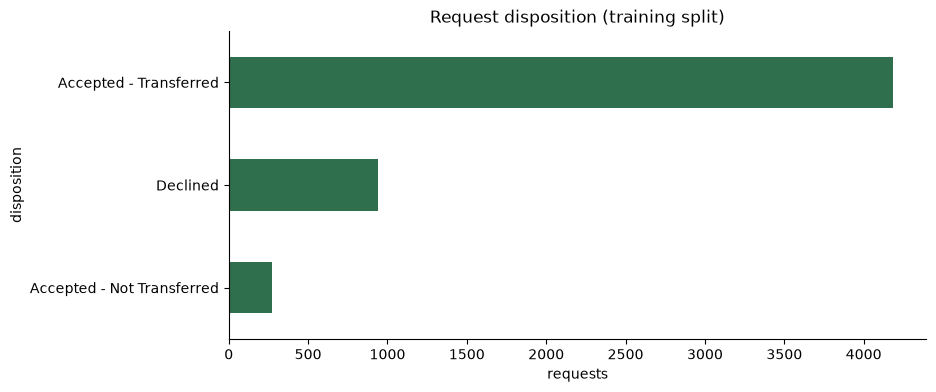

decline reasons:


decline_reason
No bed capacity                             497
No service / specialty availability         157
Insurance / authorization issue             100
Accepting physician unavailable              99
Patient stabilized at referring facility     88
Name: count, dtype: int64

In [3]:
funnel = train['disposition'].value_counts()
display(funnel)
ax = funnel.plot.barh(color='#2f6f4e', title='Request disposition (training split)')
ax.invert_yaxis(); plt.xlabel('requests'); plt.show()
print('decline reasons:')
display(train.loc[train['declined'] == 1, 'decline_reason'].value_counts())

## Demand: who sends, and when

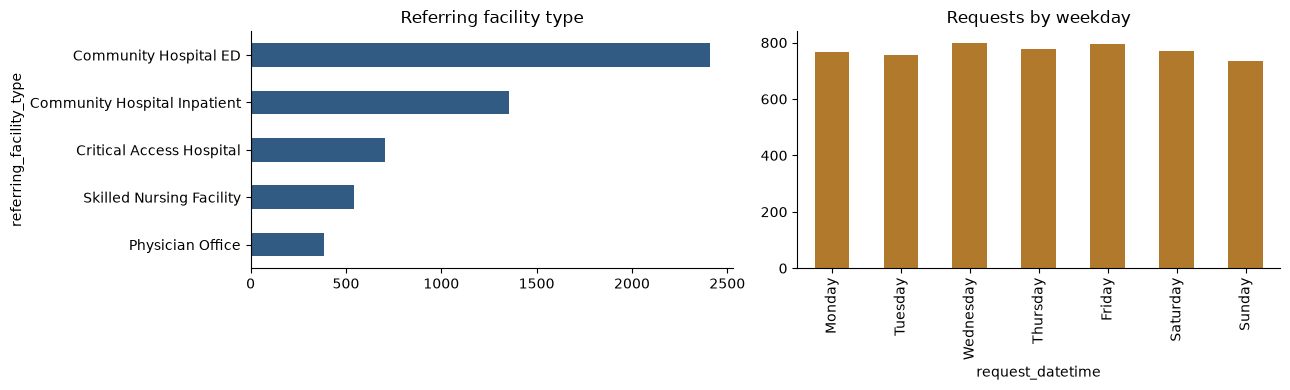

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
train['referring_facility_type'].value_counts().plot.barh(ax=axes[0], color='#315b83', title='Referring facility type')
axes[0].invert_yaxis()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
train['request_datetime'].dt.day_name().value_counts().reindex(order).plot.bar(ax=axes[1], color='#b0792b', title='Requests by weekday')
plt.tight_layout(); plt.show()

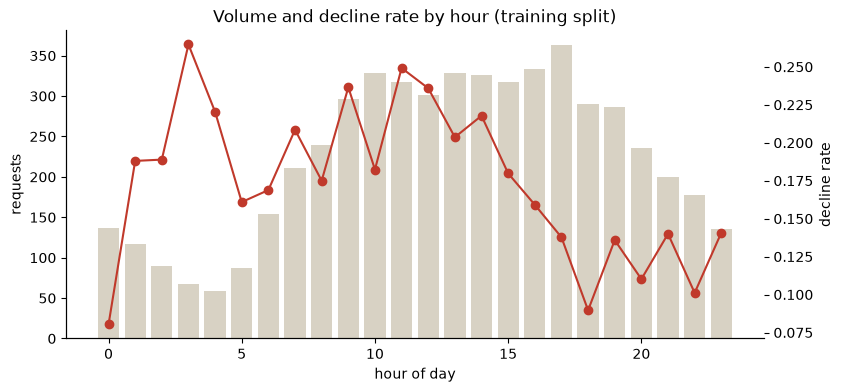

In [5]:
hourly = train.groupby('request_hour')['declined'].agg(n='size', rate='mean')
fig, ax1 = plt.subplots()
ax1.bar(hourly.index, hourly['n'], color='#d8d2c4'); ax1.set_xlabel('hour of day'); ax1.set_ylabel('requests')
ax2 = ax1.twinx(); ax2.plot(hourly.index, hourly['rate'], color='#c0392b', marker='o'); ax2.set_ylabel('decline rate')
plt.title('Volume and decline rate by hour (training split)'); plt.show()

## Where declines concentrate

In [6]:
for col in ['requested_level_of_care', 'requested_service_line', 'acuity_score']:
    display(train.groupby(col)['declined'].agg(n='size', rate='mean').sort_values('rate', ascending=False))

,n,rate
requested_level_of_care,,
Med-Surg,2058,0.188047
ICU,1722,0.166667
Progressive Care / Stepdown,1620,0.164815


,n,rate
requested_service_line,,
Oncology,319,0.282132
Orthopedics,248,0.270161
GI,406,0.268473
Vascular,340,0.191176
Cardiology,1032,0.189922
General Surgery,668,0.175150
Medical / Hospitalist,1063,0.174036
Neurology / Stroke,849,0.087161
Trauma,475,0.080000


,n,rate
acuity_score,,
1.0,172,0.226744
2.0,928,0.190733
3.0,1700,0.175882
4.0,1667,0.172166
5.0,849,0.146054


,n,rate
medsurg_occ_band,,
<85%,2164,0.069316
85-95%,2331,0.184899
>95%,905,0.397790


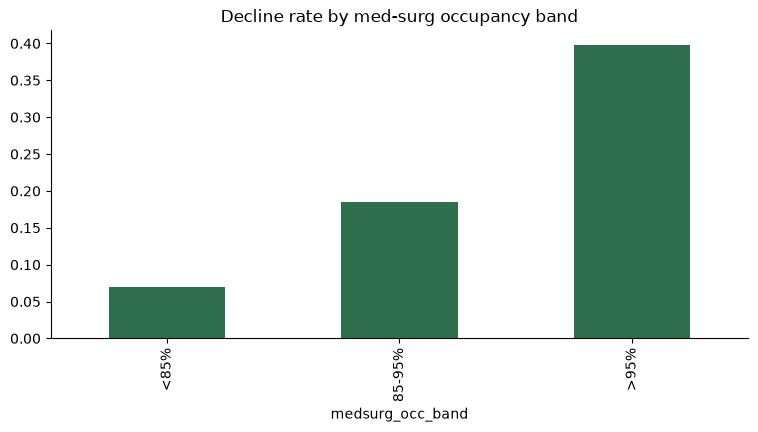

In [7]:
import numpy as np
train['medsurg_occ_band'] = pd.cut(train['medsurg_occupancy_pct'], [0, 0.85, 0.95, 1.01], labels=['<85%','85-95%','>95%'])
display(train.groupby('medsurg_occ_band', observed=True)['declined'].agg(n='size', rate='mean'))
train.groupby('medsurg_occ_band', observed=True)['declined'].mean().plot.bar(color='#2f6f4e', title='Decline rate by med-surg occupancy band'); plt.show()

## Reading it
Declines track capacity (occupancy, ED boarding) and acuity far more than time of day. `No bed capacity` is the dominant decline reason. These are the relationships the generator was built with — the value here is that the later model agrees with a picture we can already see, not that we have discovered how transfer centers behave.